In [1]:
import re
import glob
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
from scipy.interpolate import RegularGridInterpolator

In [2]:
N, M = 9, 6
beta = 0
nnn = 0.1
DM = 0.1
operator = '+-'
AB = "4950"
ox, oy = 'f', 'f'

# files = glob.glob(f"./v2/Chi_{N}{M}_DM{DM}*_Oxf_Oyf_Q*_beta{beta}*{operator}.csv")
# files = glob.glob(f"Chi_{N}{M}_nnn{nnn}*_DM{DM}*_Oxf_Oyf_AB{AB}_*_beta{beta}*{operator}.csv")
# files = glob.glob(f"./T2_test/Chi_{N}{M}_nnn{nnn}*_DM{DM}*_Oxf_Oy*_*_GS*{operator}*.csv")
# files = sorted(glob.glob(f"./HC_data/Chi_{N}{M}_nnn{nnn}*_DM{DM}*_Ox{ox}_Oy{oy}_AB{AB}_*K-_GS*{operator}*.csv"))
# files

files = glob.glob(f"./HC_data/Chi_*_DM{DM}*_Ox{ox}_Oy{oy}_AB*_*K-_*.csv")

def sort_k(filename):
    match = re.search(r'(\d*\.?\d+)K-', filename)
    return float(match.group(1))
files = sorted(files, key=sort_k)
files

['./HC_data/Chi_66_nnn0.10_DM0.10_Oxf_Oyf_AB4950_.00K-_GS_psi-10_Time60_k10_+-.csv',
 './HC_data/Chi_1212_nnn0.10_DM0.10_Oxf_Oyf_AB9798_.25K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_99_nnn0.10_DM0.10_Oxf_Oyf_AB7374_.33K-_GS_psi-10_Time60_k10_+-.csv',
 './HC_data/Chi_77_nnn0.10_DM0.10_Oxf_Oyf_AB5758_.43K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_66_nnn0.10_DM0.10_Oxf_Oyf_AB4950_.50K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_99_nnn0.10_DM0.10_Oxf_Oyf_AB7374_.67K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_88_nnn0.10_DM0.10_Oxf_Oyf_AB6566_.75K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_77_nnn0.10_DM0.10_Oxf_Oyf_AB5758_.86K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_66_nnn0.10_DM0.10_Oxf_Oyf_AB4950_1.0K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_88_nnn0.10_DM0.10_Oxf_Oyf_AB6566_1.125K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_99_nnn0.10_DM0.10_Oxf_Oyf_AB7374_1.3K-_GS_psi-10_Time120_k10_+-.csv',
 './HC_data/Chi_66_nnn0.10_DM0.10_Oxf_Oyf_AB4950_1.5

In [18]:
6/8

0.75

In [37]:
def interpolated_band(filenames, q_list, sigma):
    
    k_points = np.array(q_list)
    w = np.linspace(0, 5, 401)
    S = []
    
    # gaussian window
    gaussian = lambda x, sigma: np.exp(-(x/sigma)**2/2)
    
    # read S(t), FT to S(w)
    for file_ in filenames:
        data = pd.read_csv(file_)
        chi_re = list(data.RS)
        chi_im = list(data.IS)
        Time = np.array(data.t)
        
        if sigma > 0:
            Amp = gaussian(Time, sigma*Time[-1])
        else:
            Amp = np.ones(len(Time))

        dt = Time[1]-Time[0]
        sqT = 1/np.sqrt(2*Time[-1])
        
        for idx, omega in enumerate(w):
            int_sum = 0
            for i in range(len(Time)):
                int_sum += sqT * 2*np.cos(omega * Time[i]) * chi_re[i] * Amp[i]
                int_sum -= sqT * 2*np.sin(omega * Time[i]) * chi_im[i] * Amp[i]
            S.append(int_sum*dt)
        
    dsf_list = np.array(S).reshape(len(filenames), len(w)).T
    
    k_fine = np.linspace(k_points.min(), k_points.max(), 200)
    
    interp = RegularGridInterpolator(
        (w, k_points), dsf_list, method='slinear', fill_value=0)
    k_fine_grid, omega_grid = np.meshgrid(k_fine, w)
    pts = np.array([omega_grid.flatten(), k_fine_grid.flatten()]).T 
    S_interpolated = interp(pts).reshape(len(w), len(k_fine))
    
    return S_interpolated, w, k_fine

In [39]:
q_list = np.array([0, 0.25, 1/3, 3/7, 0.5, 2/3, 6/8, 6/7, 1, 9/8, 4/3, 1.5])*2/3
S_interpolated, w, k_fine = interpolated_band(files, q_list, 0.5)

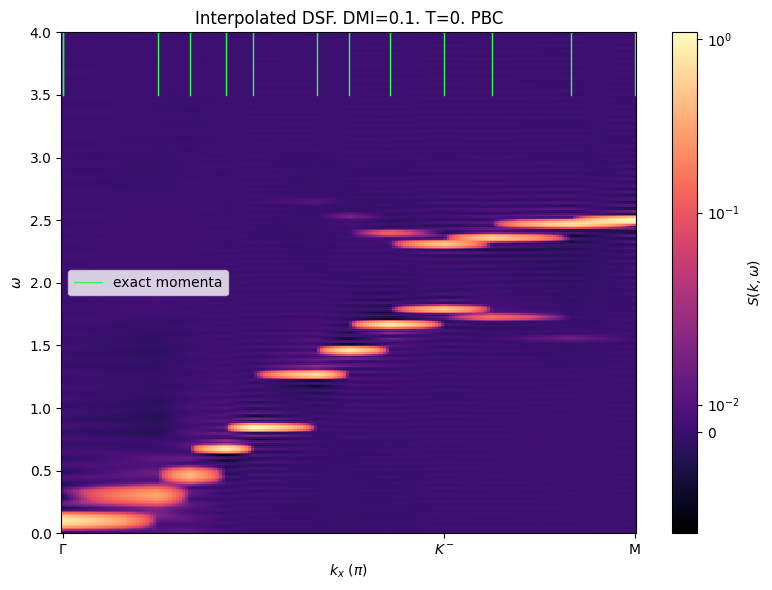

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

mesh = ax.pcolormesh(k_fine, w, S_interpolated, 
    shading='auto'
    , norm=colors.SymLogNorm(linthresh=0.07)
    , cmap='magma'
    # , vmax=0.5
    )

fig.colorbar(mesh, ax=ax, label='$S(k, \\omega)$')

ax.plot([q_list[0], q_list[0]], [3.5, 4], lw=1, c="#28FF4C", label='exact momenta')
for qi in q_list:
    ax.plot([qi, qi], [3.5, 4], lw=1, c="#28FF4C")

ax.set_xlabel('$k_x$ ($\\pi$)')
ax.set_xticks([0, 2/3, 1])
ax.set_xticklabels(['$\\Gamma$', '$K^-$', 'M'])
ax.set_ylabel('$\\omega$')
ax.set_ylim(0, 4)
ax.legend(loc='center left')
# ax.set_title(f'Interpolated DSF, {N}x{M}. DMI={DM}. T=0. PBC')
ax.set_title(f'Interpolated DSF. DMI={DM}. T=0. PBC')

plt.tight_layout()
plt.show()